# Model Training and Analysis

This notebook prepares deep-learning experiments for image watermarking, runs training on a small subset and the full dataset, and compares their results.

In [15]:
import os
import sys
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.data import get_dataloaders
from src.train import TrainConfig, fit, run_training
from src.utils import SEED

In [8]:
DATA_DIR = Path("../data")
SPLITS_FILE = DATA_DIR / "splits.json"

## Helper Functions

We will first define functions for preparing a smaller split and for loading, summarizing and visualizing the results.

In [9]:
def make_subset_splits_file(source_splits_file, output_splits_file, n_train=16, n_val=4, n_test=4):
    """Create a small split with the first `n` images of each split from an existing one."""

    with open(source_splits_file, "r") as f:
        splits = json.load(f)

    subset = {
        "train": splits["train"][:n_train],
        "val": splits["val"][:n_val],
        "test": splits["test"][:n_test],
    }

    output_splits_file = Path(output_splits_file)
    output_splits_file.parent.mkdir(parents=True, exist_ok=True)
    with output_splits_file.open("w") as f:
        json.dump(subset, f, indent=2)

    return output_splits_file

In [28]:
def clear_training_log(log_path):
    """Remove an old log before starting a fresh experiment."""

    log_path = Path(log_path)
    if log_path.exists():
        log_path.unlink()


def load_training_log(log_path):
    """Load a log file written by training function into a pandas DataFrame."""

    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(f"No log file found at {log_path}")

    return pd.read_csv(log_path)


def summarize_training_log(df, name="", show_validation=True):
    """Print the best and last epoch statistics."""

    selection_metric = "val_loss" if show_validation else "train_loss"
    best_row = df.loc[df[selection_metric].idxmin()]
    last_row = df.iloc[-1]

    title = f"Summary for {name}" if name else "Summary"
    print(title)
    print("-" * len(title))
    print(f"Epochs run: {int(last_row['epoch'])}")
    print(
        f"Best result by {selection_metric}: "
        f"epoch {int(best_row['epoch'])}"
    )
    print(
        f"  train: loss={best_row['train_loss']:.4f}, "
        f"BER={best_row['train_ber']:.4f}, "
        f"exact_accuracy={best_row['train_exact_accuracy']:.4f}, "
        f"PSNR={best_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={best_row['val_loss']:.4f}, "
            f"BER={best_row['val_ber']:.4f}, "
            f"exact_accuracy={best_row['val_exact_accuracy']:.4f}, "
            f"PSNR={best_row['val_psnr']:.2f}"
        )
    print("Last epoch:")
    print(
        f"  train: loss={last_row['train_loss']:.4f}, "
        f"BER={last_row['train_ber']:.4f}, "
        f"exact_accuracy={last_row['train_exact_accuracy']:.4f}, "
        f"PSNR={last_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={last_row['val_loss']:.4f}, "
            f"BER={last_row['val_ber']:.4f}, "
            f"exact_accuracy={last_row['val_exact_accuracy']:.4f}, "
            f"PSNR={last_row['val_psnr']:.2f}"
        )

    return best_row, last_row


def plot_training_log(
    df,
    name="",
    metrics=("loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"),
    show_validation=True,
):
    """Plot metric curves from a training log."""

    metrics = [m for m in metrics if f"train_{m}" in df.columns or f"val_{m}" in df.columns]
    n_cols = 3
    n_rows = -(-len(metrics) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for i, metric in enumerate(metrics):
        ax = axes[i // n_cols][i % n_cols]
        if f"train_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"train_{metric}"], label="train")
        if show_validation and f"val_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"val_{metric}"], label="val")
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()

    for j in range(len(metrics), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.suptitle(name)
    fig.tight_layout()
    plt.show()


def analyze_run(log_path, name="", show_validation=True):
    """Load, summarize and plot a training run log file."""

    df = load_training_log(log_path)
    summarize_training_log(
        df,
        name=name,
        show_validation=show_validation,
    )
    plot_training_log(
        df,
        name=name,
        show_validation=show_validation,
    )
    return df

## Tiny-Set Overfitting Check

We train on eight images with fixed messages and no image-quality penalty. The goal is to verify that the encoder-decoder pipeline can fully memorize a small training set before running full-dataset experiments.

In [21]:
SMALL_SPLIT_FILE = make_subset_splits_file(
    SPLITS_FILE,
    DATA_DIR / "splits_small.json",
    n_train=8,
    n_val=0,
    n_test=0,
)
SMALL_SPLIT_FILE

WindowsPath('../data/splits_small.json')

Summary for Tiny overfit test
-----------------------------
Epochs run: 200
Best result by train_loss: epoch 200
  train: loss=0.0022, BER=0.0000, exact_accuracy=1.0000, PSNR=5.96
Last epoch:
  train: loss=0.0022, BER=0.0000, exact_accuracy=1.0000, PSNR=5.96


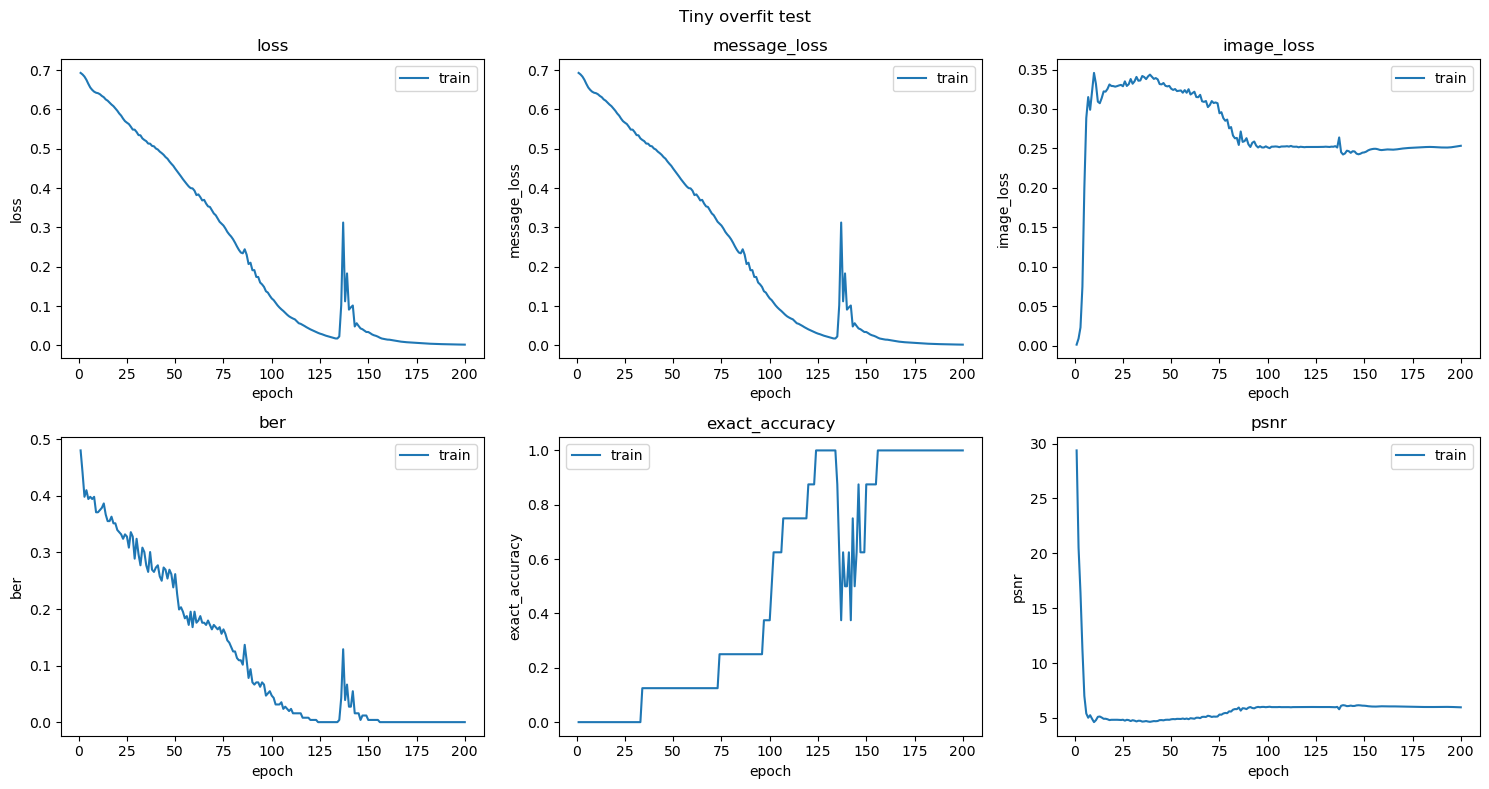

In [29]:
small_config = TrainConfig(
    experiment_name="tiny-overfit",
    epochs=200,
    batch_size=8,
    message_length=32,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/small_overfit/checkpoints",
    log_path="../results/small_overfit/experiments.csv",
)

clear_training_log(small_config.log_path)

with open(SMALL_SPLIT_FILE, "r") as f:
    n_train_images = len(json.load(f)["train"])

fixed_train_messages = torch.randint(
    0,
    2,
    (n_train_images, small_config.message_length),
    generator=torch.Generator().manual_seed(SEED),
    dtype=torch.float32,
)

small_train_loader, _, _ = get_dataloaders(
    DATA_DIR,
    SMALL_SPLIT_FILE,
    batch_size=small_config.batch_size,
    num_workers=0,
    shuffle_train=False,
)

small_encoder, small_decoder, small_history = fit(
    train_loader=small_train_loader,
    val_loader=small_train_loader,
    config=small_config,
    fixed_train_messages=fixed_train_messages,
    fixed_val_messages=fixed_train_messages,
)

small_df = analyze_run(
    small_config.log_path,
    name="Tiny overfit test",
    show_validation=False,
)

### Tiny Overfit Test Results

The model fully memorized all eight fixed 32-bit messages after 200 epochs. The final training BER is 0, exact message accuracy is 1, and message loss is approximately 0.002.

PSNR is intentionally poor because `image_loss_weight=0` in this diagnostic experiment. Image quality will be optimized during baseline training.

## Clean Baseline Experiment Summary

All full-dataset runs below used the same train/validation split and no noise attacks. Exact message accuracy remained `0` for every full-dataset experiment.

| Experiment | Message bits | Main change | Best validation BER | Validation PSNR (dB) | Conclusion |
|---|---:|---|---:|---:|---|
| Message-only | 32 | No image loss, 40 epochs | 0.3657 | 7.55 | Learns a message signal, but destroys image quality |
| Loss weight 0.03 | 32 | Image loss weight 0.03 | 0.4084 | 11.15 | Better images, insufficient recovery |
| Loss weight 0.10 | 32 | Image loss weight 0.10 | 0.4381 | 15.27 | Higher PSNR, worse BER |
| Loss weight 0.30 | 32 | Image loss weight 0.30 | 0.4314 | 19.16 | Still not a usable baseline |
| Small model | 32 | Fewer channels, 20 epochs | 0.4321 | 20.94 | Similar BER with lower cost |
| Small model continued | 32 | Same checkpoint, 40 epochs | 0.4390 | 20.95 | More epochs do not solve recovery |
| Wide model | 32 | More channels | 0.4914 | 66.48 | Collapses to image preservation |
| Constrained baseline | 16 | `max_delta=0.03` | 0.4644 | 30.56 | Good image quality, poor recovery |
| Average-pooling check | 16 | Average instead of max pooling | 0.4489 | 30.55 | Small gain, still far from the BER target |

The constrained 16-bit tiny test did succeed on eight fixed images: BER `0`, exact message accuracy `1`, and PSNR `30.62` dB. This confirms that the bounded encoder-decoder pipeline can memorize a small set, but the current decoder does not generalize to unseen images.

Loss weighting, channel width, longer training, shorter messages, and average pooling were therefore stopped. The next experiment uses a different architecture with deeper convolutional processing, no local pooling, BatchNorm, and masked global average pooling. Noise remains disabled until a usable clean baseline is obtained.